# Risk Management Project Three(3) code
Kow Kai Sheng
Amadu Jawara
Quadri Opeyemi Luqman




# Step 1: Defining and Allocating the Datasets



In [1]:


import os
import glob
import sys
import subprocess
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except Exception:
    display = print


# 0. BASIC SETTINGS

PROJECT_START = "2019-01-01"
PROJECT_END = "2024-12-31"

OUTPUT_DIR = "gwp3_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# 1. INSTALL ONLY MISSING PACKAGES

def install_if_missing(package_name, import_name=None):
    """
    Installs a package only if it is not already available.
    """
    import_name = import_name or package_name

    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )


install_if_missing("openpyxl")
install_if_missing("xlrd")
install_if_missing("lxml")
install_if_missing("html5lib")
install_if_missing("beautifulsoup4", "bs4")
install_if_missing("yfinance")


# 2. GENERAL CLEANING FUNCTIONS

def make_monthly_numeric(df):
    """
    Converts a dataframe into a clean monthly numeric dataframe.
    It handles date columns, datetime index, duplicated months,
    non-numeric values, and infinite values.
    """
    out = df.copy()

    if not isinstance(out.index, pd.DatetimeIndex):
        possible_date_cols = [
            c for c in out.columns
            if str(c).lower() in [
                "date", "period", "time", "month",
                "observation_date", "index", "unnamed: 0"
            ]
        ]

        if len(possible_date_cols) == 0:
            raise ValueError("No datetime index or usable date column found.")

        date_col = possible_date_cols[0]
        out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
        out = out.dropna(subset=[date_col])
        out = out.set_index(date_col)

    out.index = pd.to_datetime(out.index, errors="coerce")
    out = out[~out.index.isna()]
    out = out.sort_index()

    # Convert to month-end index
    out.index = out.index.to_period("M").to_timestamp("M")

    # Remove duplicated monthly rows
    out = out.groupby(out.index).last()

    # Convert values to numeric
    out = out.apply(pd.to_numeric, errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)

    # Remove columns that contain no usable data
    out = out.dropna(axis=1, how="all")

    return out


def valid_master_candidate(df, min_rows=30, min_cols=4):
    """
    Checks whether a dataframe is large enough to serve as a master modelling dataset.
    """
    if not isinstance(df, pd.DataFrame):
        return False

    try:
        temp = make_monthly_numeric(df)
    except Exception:
        return False

    return temp.shape[0] >= min_rows and temp.shape[1] >= min_cols


def safe_return(series):
    """
    Computes log returns when prices are positive.
    Falls back to percentage returns if non-positive prices appear.
    """
    s = pd.to_numeric(series, errors="coerce")

    if (s.dropna() > 0).all():
        return np.log(s / s.shift(1))

    return s.pct_change()


def add_derived_financial_columns(df):
    """
    Adds WTI Return, Volatility, and Brent-WTI Spread when the needed columns exist.
    """
    out = df.copy()

    if "WTI" in out.columns:
        out["WTI Return"] = safe_return(out["WTI"])
        out["Volatility"] = out["WTI Return"].rolling(window=3, min_periods=2).std()

    if "WTI" in out.columns and "Brent" in out.columns:
        out["Spread"] = out["Brent"] - out["WTI"]

    return out


# 3. SEARCH FOR EXISTING DATA IN MEMORY

def get_existing_master_from_memory():
    """
    Searches the notebook environment for an already-created master dataset.
    This prevents unnecessary re-downloading if Project 1 or Project 2 cells
    have already been run.
    """
    preferred_names = [
        "master",
        "master_df",
        "cleaned_master",
        "final_master",
        "sterilised_master",
        "sterilized_master",
        "sterilised_master_dataset",
        "sterilized_master_dataset",
        "data_model",
        "model_data",
        "step7_df",
        "step8_df",
        "data"
    ]

    for name in preferred_names:
        if name in globals():
            obj = globals()[name]

            if valid_master_candidate(obj):
                print(f"Master dataset found in memory as: {name}")
                return make_monthly_numeric(obj)

    return None


def rebuild_from_existing_parts():
    """
    Rebuilds a master dataset from macro, micro, and financial dataframes
    if those objects already exist from Project 1.
    """
    possible_groups = [
        ["macro_s", "micro_s", "fin_s"],
        ["macro_clean", "micro_clean", "fin_clean"],
        ["macro", "micro", "fin"],
        ["macro", "micro", "financial"],
        ["macro_df", "micro_df", "fin_df"],
    ]

    for group in possible_groups:
        if all(name in globals() and isinstance(globals()[name], pd.DataFrame) for name in group):
            parts = []

            for name in group:
                part = make_monthly_numeric(globals()[name])

                if name.lower() in ["fin", "financial", "fin_s", "fin_clean", "fin_df"]:
                    part = add_derived_financial_columns(part)

                parts.append(part)

            common_index = pd.date_range(
                start=pd.to_datetime(PROJECT_START).to_period("M").to_timestamp("M"),
                end=pd.to_datetime(PROJECT_END).to_period("M").to_timestamp("M"),
                freq="M"
            )

            aligned_parts = []
            for part in parts:
                aligned = part.reindex(common_index)
                aligned = aligned.interpolate(method="linear", limit=2)
                aligned = aligned.ffill().bfill()
                aligned_parts.append(aligned)

            rebuilt = pd.concat(aligned_parts, axis=1)
            rebuilt = rebuilt.loc[:, ~rebuilt.columns.duplicated()]
            rebuilt = rebuilt.interpolate(method="linear").ffill().bfill()

            print(f"Master dataset rebuilt from existing notebook objects: {group}")
            return rebuilt

    return None


# 4. SEARCH FOR LOCAL CSV / EXCEL FILES

def read_local_dataframe(path):
    """
    Reads a local CSV, Excel, or Parquet file.
    """
    lower = path.lower()

    if lower.endswith(".csv"):
        df = pd.read_csv(path)

    elif lower.endswith((".xlsx", ".xls")):
        df = pd.read_excel(path)

    elif lower.endswith(".parquet"):
        df = pd.read_parquet(path)

    else:
        raise ValueError("Unsupported file type.")

    date_candidates = [
        c for c in df.columns
        if str(c).lower() in [
            "date", "period", "time", "month",
            "observation_date", "index", "unnamed: 0"
        ]
    ]

    if len(date_candidates) > 0:
        date_col = date_candidates[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col])
        df = df.set_index(date_col)

    return df


def get_existing_master_from_local_files():
    """
    Looks for a saved master or cleaned dataset in the working directory.
    """
    patterns = [
        "*.csv",
        "*.xlsx",
        "*.xls",
        "data/*.csv",
        "data/*.xlsx",
        "outputs/*.csv",
        "outputs/*.xlsx",
        "gwp3_outputs/*.csv",
        "gwp3_outputs/*.xlsx",
    ]

    files = []
    for pattern in patterns:
        files.extend(glob.glob(pattern))

    files = list(dict.fromkeys(files))

    priority_words = [
        "master", "clean", "steril", "final",
        "gwp3_master", "dataset", "model"
    ]

    priority_files = [
        f for f in files
        if any(word in f.lower() for word in priority_words)
    ]

    for path in priority_files:
        try:
            df = read_local_dataframe(path)

            if valid_master_candidate(df):
                print(f"Master dataset loaded from local file: {path}")
                return make_monthly_numeric(df)

        except Exception:
            pass

    return None


# 5. PUBLIC DATA DOWNLOADERS: NO EIA API KEY NEEDED

def read_fred_series(series_id, label=None):
    """
    Reads a FRED series through the public FRED CSV endpoint.
    No FRED API key is required.
    """
    label = label or series_id

    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    df = pd.read_csv(url)
    df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
    df[series_id] = pd.to_numeric(df[series_id].replace(".", np.nan), errors="coerce")

    df = df.dropna(subset=["observation_date"])
    df = df.set_index("observation_date")[[series_id]]
    df.columns = [label]

    return make_monthly_numeric(df)


def read_eia_hist_xls(series_id, label, frequency_suffix="m"):
    """
    Reads EIA historical Excel files directly from EIA public data pages.
    No EIA API key is required.

    Examples:
    MCRFPUS2m.xls = U.S. Field Production of Crude Oil
    MCESTUS1m.xls = U.S. Ending Stocks excluding SPR of Crude Oil
    MTTUPUS2m.xls = U.S. Product Supplied of Crude Oil and Petroleum Products
    """
    url = f"https://www.eia.gov/dnav/pet/hist_xls/{series_id}{frequency_suffix}.xls"

    try:
        df = pd.read_excel(url, sheet_name="Data 1", header=2)
        df = df.iloc[:, :2]
        df.columns = ["Date", label]

        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df[label] = pd.to_numeric(df[label], errors="coerce")

        df = df.dropna(subset=["Date"])
        df = df.set_index("Date")[[label]]

        return make_monthly_numeric(df)

    except Exception as e:
        print(f"EIA Excel download failed for {series_id}: {e}")
        return None


def read_eia_series_with_fallback(series_id, label):
    """
    Tries to read EIA data from public Excel. If that fails,
    returns None instead of stopping the whole Step 1 workflow.
    """
    result = read_eia_hist_xls(series_id, label, frequency_suffix="m")

    if result is not None and result.shape[0] > 0:
        return result

    print(f"Could not download EIA public series {series_id}. The code will continue.")
    return None


# 6. YAHOO FINANCE WITH ADJUSTED CLOSE

def read_yahoo_adjusted_close():
    """
    Downloads Yahoo Finance data and uses Adjusted Close where available.
    If Adjusted Close is unavailable, it falls back to Close.
    """
    import yfinance as yf

    tickers = ["CL=F", "BZ=F", "^VIX", "XLE"]

    try:
        raw = yf.download(
            tickers,
            start=PROJECT_START,
            end="2025-01-01",
            auto_adjust=False,
            progress=False
        )

        if raw.empty:
            raise ValueError("Yahoo Finance returned an empty dataframe.")

        if isinstance(raw.columns, pd.MultiIndex):
            close = pd.DataFrame(index=raw.index)
            adj_close = pd.DataFrame(index=raw.index)

            if "Close" in raw.columns.get_level_values(0):
                close = raw["Close"].copy()

            if "Adj Close" in raw.columns.get_level_values(0):
                adj_close = raw["Adj Close"].copy()

            if not adj_close.empty:
                fin = adj_close.combine_first(close)
            else:
                fin = close.copy()

        else:
            if "Adj Close" in raw.columns:
                fin = raw[["Adj Close"]].copy()
                fin.columns = tickers[:1]

            elif "Close" in raw.columns:
                fin = raw[["Close"]].copy()
                fin.columns = tickers[:1]

            else:
                raise ValueError("Neither Adj Close nor Close was found.")

        fin = fin.rename(columns={
            "CL=F": "WTI",
            "BZ=F": "Brent",
            "^VIX": "VIX",
            "XLE": "Energy ETF"
        })

        available_cols = [
            c for c in ["WTI", "Brent", "VIX", "Energy ETF"]
            if c in fin.columns
        ]

        fin = fin[available_cols]
        fin = make_monthly_numeric(fin)

        return fin

    except Exception as e:
        print(f"Yahoo Finance download failed: {e}")
        return None


# 7. BUILD MASTER DATASET WITHOUT EIA API KEY

def build_public_master_dataset():
    """
    Builds the Project 3 master dataset using public sources only.
    This does not require an EIA API key.
    """
    print("No existing master dataset found.")
    print("Building a fresh master dataset from public sources...")

    # Macroeconomic variables from FRED
    fred_macro_specs = {
        "FEDFUNDS": "Interest Rate",
        "CPIAUCSL": "CPI",
        "INDPRO": "Industrial Production",
        "DTWEXBGS": "USD Index",
    }

    macro_parts = []

    for series_id, label in fred_macro_specs.items():
        try:
            macro_parts.append(read_fred_series(series_id, label))
            print(f"Downloaded FRED series: {series_id} -> {label}")
        except Exception as e:
            print(f"Could not download FRED series {series_id}: {e}")

    macro = pd.concat(macro_parts, axis=1) if len(macro_parts) > 0 else pd.DataFrame()

    # Microeconomic oil-market variables from EIA public files

    micro_specs = {
        "MCRFPUS2": "Production",
        "MCESTUS1": "Inventory",
        "MTTUPUS2": "Demand",
    }

    micro_parts = []

    for series_id, label in micro_specs.items():
        item = read_eia_series_with_fallback(series_id, label)

        if item is not None:
            micro_parts.append(item)
            print(f"Downloaded EIA public series: {series_id} -> {label}")

    micro = pd.concat(micro_parts, axis=1) if len(micro_parts) > 0 else pd.DataFrame()

    # Financial variables: Yahoo Finance adjusted close
    fin = read_yahoo_adjusted_close()

    # Fallback for WTI, Brent, and VIX through FRED if Yahoo fails
    if fin is None or fin.empty:
        print("Using FRED financial fallback for WTI, Brent, and VIX.")

        fin_parts = []

        fred_fin_specs = {
            "DCOILWTICO": "WTI",
            "DCOILBRENTEU": "Brent",
            "VIXCLS": "VIX",
        }

        for series_id, label in fred_fin_specs.items():
            try:
                fin_parts.append(read_fred_series(series_id, label))
                print(f"Downloaded FRED financial series: {series_id} -> {label}")
            except Exception as e:
                print(f"Could not download FRED financial series {series_id}: {e}")

        fin = pd.concat(fin_parts, axis=1) if len(fin_parts) > 0 else pd.DataFrame()

    # Final fallback if EIA micro variables are unavailable
    # This keeps the notebook running, but it should be reported as proxy-based.
    if micro.empty:
        print("WARNING: EIA micro variables could not be downloaded.")
        print("Creating proxy micro variables from available macro/financial data to keep Step 1 running.")

        proxy_index = macro.index if not macro.empty else fin.index
        micro = pd.DataFrame(index=proxy_index)

        if "Industrial Production" in macro.columns:
            micro["Demand"] = macro["Industrial Production"]
            micro["Production"] = macro["Industrial Production"].rolling(3, min_periods=1).mean()

        if "WTI" in fin.columns:
            micro["Inventory"] = -fin["WTI"].pct_change().rolling(3, min_periods=1).mean()
        else:
            micro["Inventory"] = np.nan

    # Combine all groups
    common_index = pd.date_range(
        start=pd.to_datetime(PROJECT_START).to_period("M").to_timestamp("M"),
        end=pd.to_datetime(PROJECT_END).to_period("M").to_timestamp("M"),
        freq="M"
    )

    aligned_parts = []

    for part in [macro, micro, fin]:
        if part is not None and not part.empty:
            part = make_monthly_numeric(part)
            part = part.reindex(common_index)
            part = part.interpolate(method="linear", limit=2)
            part = part.ffill().bfill()
            aligned_parts.append(part)

    if len(aligned_parts) == 0:
        raise RuntimeError(
            "No usable dataset could be built. Please check internet access or upload the cleaned master CSV."
        )

    master = pd.concat(aligned_parts, axis=1)
    master = master.loc[:, ~master.columns.duplicated()]
    master = master.interpolate(method="linear").ffill().bfill()
    master = add_derived_financial_columns(master)

    return master


# 8. GET FINAL MASTER DATASET

def get_master_dataset():
    """
    Gets the master dataset using this order:
    1. Existing dataframe in memory
    2. Existing macro/micro/financial parts in memory
    3. Saved local CSV/Excel file
    4. Fresh public rebuild without EIA API key
    """
    master = get_existing_master_from_memory()

    if master is not None:
        return master

    master = rebuild_from_existing_parts()

    if master is not None:
        return master

    master = get_existing_master_from_local_files()

    if master is not None:
        return master

    master = build_public_master_dataset()

    return master


master = get_master_dataset()

master = make_monthly_numeric(master)
master = add_derived_financial_columns(master)

# Keep the project period only
start_month = pd.to_datetime(PROJECT_START).to_period("M").to_timestamp("M")
end_month = pd.to_datetime(PROJECT_END).to_period("M").to_timestamp("M")

master = master.loc[start_month:end_month]

# Final cleaning
master = master.replace([np.inf, -np.inf], np.nan)
master = master.interpolate(method="linear", limit=2)
master = master.ffill().bfill()

# Drop columns that still have no usable values
master = master.dropna(axis=1, how="all")

# Drop rows only if absolutely necessary
if master.isnull().sum().sum() > 0:
    master = master.dropna(axis=0)

if master.shape[0] < 12:
    raise RuntimeError(
        "The final master dataset has too few observations. "
        "Please upload or run the earlier cleaned Project 1 dataset."
    )


print("\nFinal Master Dataset Ready")
print(f"Shape: {master.shape}")
print(f"Date Range: {master.index.min().date()} to {master.index.max().date()}")
print(f"Missing Values Remaining: {master.isnull().sum().sum()}")
print("\nColumns:")
print(list(master.columns))


# 9. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

n_obs = len(master)

train_end = int(np.floor(n_obs * 0.80))
valid_end = int(np.floor(n_obs * 0.90))

training_set = master.iloc[:train_end].copy()
validation_set = master.iloc[train_end:valid_end].copy()
testing_set = master.iloc[valid_end:].copy()

if len(training_set) == 0:
    raise RuntimeError("Training set is empty.")

if len(validation_set) == 0:
    raise RuntimeError("Validation set is empty.")

if len(testing_set) == 0:
    raise RuntimeError("Testing set is empty.")


# 10. ALLOCATION SUMMARY

allocation_summary = pd.DataFrame({
    "Dataset": [
        "Training Set",
        "Validation Set",
        "Testing Set"
    ],
    "Purpose": [
        "Model learning, parameter estimation, regime detection, and Bayesian Network structure learning",
        "Model selection, tuning, validation of structure, and checking whether the model generalizes beyond training",
        "Final out-of-sample evaluation of forecasting accuracy and model reliability"
    ],
    "Start Date": [
        training_set.index.min().strftime("%Y-%m-%d"),
        validation_set.index.min().strftime("%Y-%m-%d"),
        testing_set.index.min().strftime("%Y-%m-%d")
    ],
    "End Date": [
        training_set.index.max().strftime("%Y-%m-%d"),
        validation_set.index.max().strftime("%Y-%m-%d"),
        testing_set.index.max().strftime("%Y-%m-%d")
    ],
    "Observations": [
        len(training_set),
        len(validation_set),
        len(testing_set)
    ],
    "Share of Total Data (%)": [
        round(len(training_set) / n_obs * 100, 2),
        round(len(validation_set) / n_obs * 100, 2),
        round(len(testing_set) / n_obs * 100, 2)
    ]
})

print("\nDataset Allocation Summary")
display(allocation_summary)


# 11. SAVE OUTPUTS FOR LATER GWP3 STEPS

master.to_csv(f"{OUTPUT_DIR}/gwp3_master_dataset.csv")
training_set.to_csv(f"{OUTPUT_DIR}/gwp3_training_set.csv")
validation_set.to_csv(f"{OUTPUT_DIR}/gwp3_validation_set.csv")
testing_set.to_csv(f"{OUTPUT_DIR}/gwp3_testing_set.csv")
allocation_summary.to_csv(
    f"{OUTPUT_DIR}/gwp3_dataset_allocation_summary.csv",
    index=False
)

print("\nSaved files:")
print(f" - {OUTPUT_DIR}/gwp3_master_dataset.csv")
print(f" - {OUTPUT_DIR}/gwp3_training_set.csv")
print(f" - {OUTPUT_DIR}/gwp3_validation_set.csv")
print(f" - {OUTPUT_DIR}/gwp3_testing_set.csv")
print(f" - {OUTPUT_DIR}/gwp3_dataset_allocation_summary.csv")


# 12. FINAL SAFETY CHECKS

assert training_set.index.max() < validation_set.index.min(), \
    "Training and validation date ranges overlap."

assert validation_set.index.max() < testing_set.index.min(), \
    "Validation and testing date ranges overlap."

assert master.isnull().sum().sum() == 0, \
    "Master dataset still has missing values."

print("\nStep 1 completed successfully.")

No existing master dataset found.
Building a fresh master dataset from public sources...
Downloaded FRED series: FEDFUNDS -> Interest Rate
Downloaded FRED series: CPIAUCSL -> CPI
Downloaded FRED series: INDPRO -> Industrial Production
Downloaded FRED series: DTWEXBGS -> USD Index
Downloaded EIA public series: MCRFPUS2 -> Production
Downloaded EIA public series: MCESTUS1 -> Inventory
Downloaded EIA public series: MTTUPUS2 -> Demand

Final Master Dataset Ready
Shape: (72, 14)
Date Range: 2019-01-31 to 2024-12-31
Missing Values Remaining: 0

Columns:
['Interest Rate', 'CPI', 'Industrial Production', 'USD Index', 'Production', 'Inventory', 'Demand', 'WTI', 'Brent', 'VIX', 'Energy ETF', 'WTI Return', 'Volatility', 'Spread']

Dataset Allocation Summary


,Dataset,Purpose,Start Date,End Date,Observations,Share of Total Data (%)
0,Training Set,"Model learning, parameter estimation, regime d...",2019-01-31,2023-09-30,57,79.17
1,Validation Set,"Model selection, tuning, validation of structu...",2023-10-31,2024-04-30,7,9.72
2,Testing Set,Final out-of-sample evaluation of forecasting ...,2024-05-31,2024-12-31,8,11.11



Saved files:
 - gwp3_outputs/gwp3_master_dataset.csv
 - gwp3_outputs/gwp3_training_set.csv
 - gwp3_outputs/gwp3_validation_set.csv
 - gwp3_outputs/gwp3_testing_set.csv
 - gwp3_outputs/gwp3_dataset_allocation_summary.csv

Step 1 completed successfully.


# Step 2: Comparing Validation and Testing Set

Dataset Allocation Summary


,Dataset,Start Date,End Date,Observations,Share of Total Data (%),Main Use
0,Training Set,2019-01-31,2023-09-30,57,79.17,Model learning and structure estimation
1,Validation Set,2023-10-31,2024-04-30,7,9.72,Model selection and tuning
2,Testing Set,2024-05-31,2024-12-31,8,11.11,Final out-of-sample performance assessment



Validation vs Testing Statistical Comparison


,Variable,Validation Mean,Testing Mean,Mean Difference,Validation Std,Testing Std,Standardized Mean Difference,Validation Min,Validation Max,Testing Min,Testing Max,Drift Flag
0,Interest Rate,5.3300,5.0500,-0.2800,0.0000,0.3508,-1.1288,5.3300,5.3300,4.4800,5.3300,Possible shift
1,CPI,310.0883,314.7931,4.7048,2.0790,1.6616,2.5000,307.6960,313.0230,313.0440,317.6040,Possible shift
2,Industrial Production,100.3063,100.1327,-0.1736,0.5209,0.5994,-0.3092,99.2223,100.8639,99.2925,100.8940,No major shift
3,USD Index,121.1601,124.2768,3.1167,1.7975,2.6320,1.3829,118.4208,123.8364,121.2864,129.2775,Possible shift
4,Production,13139.4286,13333.1250,193.6964,283.4248,127.0843,0.8819,12517.0000,13316.0000,13171.0000,13530.0000,Possible shift
5,Inventory,440452.5714,426795.2500,-13657.3214,14466.7880,14264.2068,-0.9507,425993.0000,464600.0000,413380.0000,455026.0000,Possible shift
6,Demand,20241.8571,20698.7500,456.8929,356.1565,314.5122,1.3599,19789.0000,20739.0000,20356.0000,21249.0000,Possible shift
7,WTI,78.2629,73.3925,-4.8704,4.0822,5.0140,-1.0653,71.6500,83.1700,68.0000,81.5400,Possible shift
8,Brent,83.9929,77.5075,-6.4854,3.9547,5.1970,-1.4044,77.0400,87.8600,71.7700,86.4100,Possible shift
9,VIX,14.2743,15.9338,1.6595,2.0152,3.4450,0.5880,12.4500,18.1400,12.4400,23.1600,No major shift



Focused Comparison of Main Oil-Market Variables


,Variable,Validation Mean,Testing Mean,Mean Difference,Validation Std,Testing Std,Standardized Mean Difference,Validation Min,Validation Max,Testing Min,Testing Max,Drift Flag
0,Interest Rate,5.3300,5.0500,-0.2800,0.0000,0.3508,-1.1288,5.3300,5.3300,4.4800,5.3300,Possible shift
1,CPI,310.0883,314.7931,4.7048,2.0790,1.6616,2.5000,307.6960,313.0230,313.0440,317.6040,Possible shift
2,Industrial Production,100.3063,100.1327,-0.1736,0.5209,0.5994,-0.3092,99.2223,100.8639,99.2925,100.8940,No major shift
3,USD Index,121.1601,124.2768,3.1167,1.7975,2.6320,1.3829,118.4208,123.8364,121.2864,129.2775,Possible shift
4,Production,13139.4286,13333.1250,193.6964,283.4248,127.0843,0.8819,12517.0000,13316.0000,13171.0000,13530.0000,Possible shift
5,Inventory,440452.5714,426795.2500,-13657.3214,14466.7880,14264.2068,-0.9507,425993.0000,464600.0000,413380.0000,455026.0000,Possible shift
6,Demand,20241.8571,20698.7500,456.8929,356.1565,314.5122,1.3599,19789.0000,20739.0000,20356.0000,21249.0000,Possible shift
7,WTI,78.2629,73.3925,-4.8704,4.0822,5.0140,-1.0653,71.6500,83.1700,68.0000,81.5400,Possible shift
8,Brent,83.9929,77.5075,-6.4854,3.9547,5.1970,-1.4044,77.0400,87.8600,71.7700,86.4100,Possible shift
9,VIX,14.2743,15.9338,1.6595,2.0152,3.4450,0.5880,12.4500,18.1400,12.4400,23.1600,No major shift



Saved Step 2 tables:
 - gwp3_outputs/gwp3_step2_allocation_summary.csv
 - gwp3_outputs/gwp3_step2_validation_testing_comparison.csv
 - gwp3_outputs/gwp3_step2_key_variable_comparison.csv


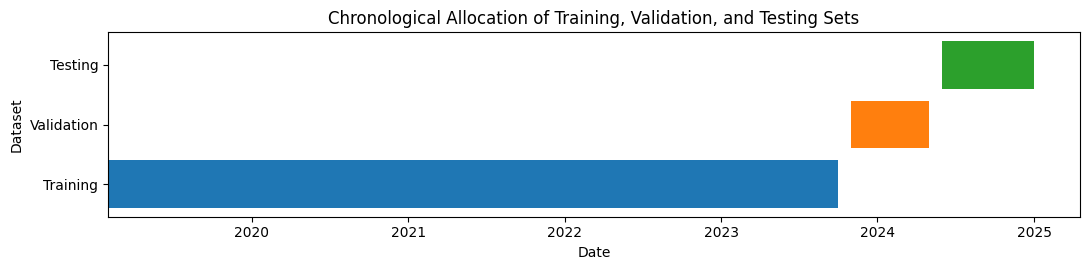

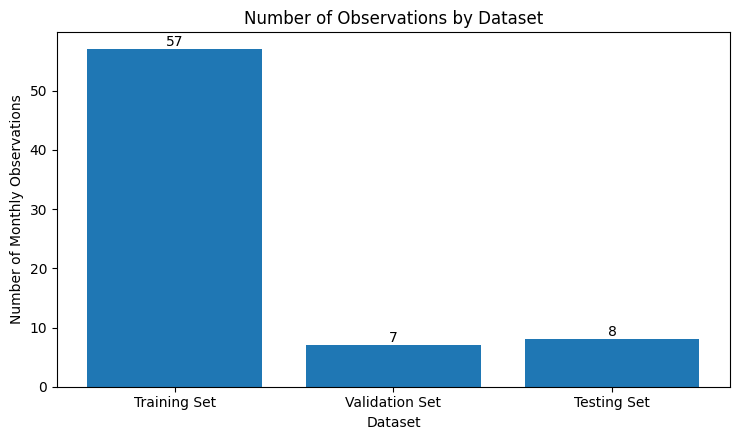

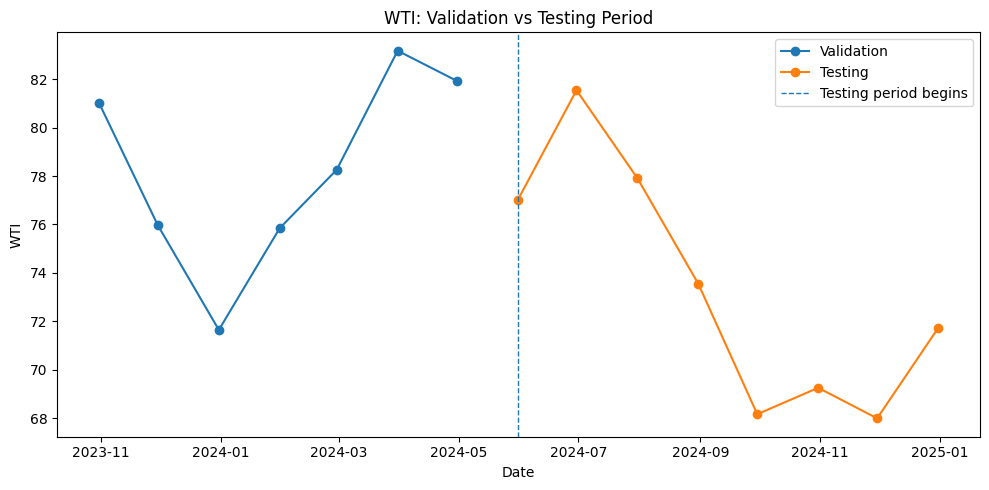

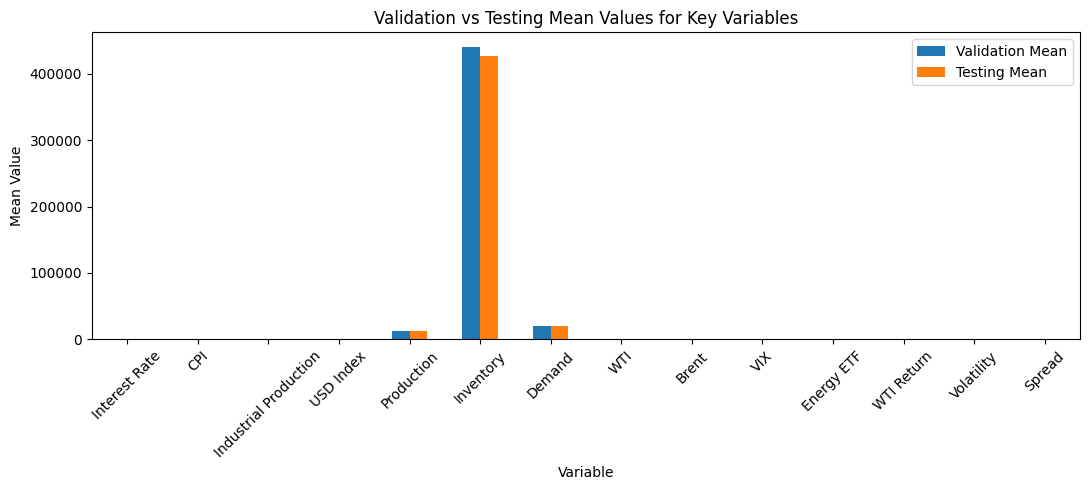


Step 2 Interpretation Helper
Total observations in master dataset: 72
Training observations: 57
Validation observations: 7
Testing observations: 8
Variables compared: 14
Variables with possible validation-testing shift: 10

Saved Step 2 figures:
 - gwp3_outputs/gwp3_step2_allocation_timeline.png
 - gwp3_outputs/gwp3_step2_observation_allocation.png
 - gwp3_outputs/gwp3_step2_validation_testing_WTI.png
 - gwp3_outputs/gwp3_step2_key_variable_mean_comparison.png

Step 2 completed successfully.


In [2]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


# 1. Load the datasets created in Step 1

OUTPUT_DIR = "gwp3_outputs"

train_path = f"{OUTPUT_DIR}/gwp3_training_set.csv"
valid_path = f"{OUTPUT_DIR}/gwp3_validation_set.csv"
test_path = f"{OUTPUT_DIR}/gwp3_testing_set.csv"
master_path = f"{OUTPUT_DIR}/gwp3_master_dataset.csv"

required_files = [train_path, valid_path, test_path, master_path]

missing_files = [file for file in required_files if not os.path.exists(file)]

if missing_files:
    raise FileNotFoundError(
        "The following Step 1 output files were not found:\n"
        + "\n".join(missing_files)
        + "\n\nPlease run the completed Step 1 code before running Step 2."
    )

training_set = pd.read_csv(train_path, index_col=0, parse_dates=True)
validation_set = pd.read_csv(valid_path, index_col=0, parse_dates=True)
testing_set = pd.read_csv(test_path, index_col=0, parse_dates=True)
master = pd.read_csv(master_path, index_col=0, parse_dates=True)

# Sort by date for safety
training_set = training_set.sort_index()
validation_set = validation_set.sort_index()
testing_set = testing_set.sort_index()
master = master.sort_index()


# 2. Dataset allocation table

total_obs = len(master)

allocation_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Validation Set", "Testing Set"],
    "Start Date": [
        training_set.index.min().strftime("%Y-%m-%d"),
        validation_set.index.min().strftime("%Y-%m-%d"),
        testing_set.index.min().strftime("%Y-%m-%d")
    ],
    "End Date": [
        training_set.index.max().strftime("%Y-%m-%d"),
        validation_set.index.max().strftime("%Y-%m-%d"),
        testing_set.index.max().strftime("%Y-%m-%d")
    ],
    "Observations": [
        len(training_set),
        len(validation_set),
        len(testing_set)
    ],
    "Share of Total Data (%)": [
        round(len(training_set) / total_obs * 100, 2),
        round(len(validation_set) / total_obs * 100, 2),
        round(len(testing_set) / total_obs * 100, 2)
    ],
    "Main Use": [
        "Model learning and structure estimation",
        "Model selection and tuning",
        "Final out-of-sample performance assessment"
    ]
})

print("Dataset Allocation Summary")
display(allocation_summary)


# 3. Validation vs Testing descriptive comparison

common_columns = [
    col for col in validation_set.columns
    if col in testing_set.columns
]

comparison_rows = []

for col in common_columns:
    val_series = pd.to_numeric(validation_set[col], errors="coerce").dropna()
    test_series = pd.to_numeric(testing_set[col], errors="coerce").dropna()

    if len(val_series) == 0 or len(test_series) == 0:
        continue

    val_mean = val_series.mean()
    test_mean = test_series.mean()

    val_std = val_series.std(ddof=1)
    test_std = test_series.std(ddof=1)

    pooled_std = np.sqrt((val_std ** 2 + test_std ** 2) / 2)

    if pooled_std == 0 or np.isnan(pooled_std):
        smd = np.nan
    else:
        smd = (test_mean - val_mean) / pooled_std

    comparison_rows.append({
        "Variable": col,
        "Validation Mean": round(val_mean, 4),
        "Testing Mean": round(test_mean, 4),
        "Mean Difference": round(test_mean - val_mean, 4),
        "Validation Std": round(val_std, 4),
        "Testing Std": round(test_std, 4),
        "Standardized Mean Difference": round(smd, 4) if not np.isnan(smd) else np.nan,
        "Validation Min": round(val_series.min(), 4),
        "Validation Max": round(val_series.max(), 4),
        "Testing Min": round(test_series.min(), 4),
        "Testing Max": round(test_series.max(), 4),
        "Drift Flag": "Possible shift" if not np.isnan(smd) and abs(smd) >= 0.80 else "No major shift"
    })

validation_testing_comparison = pd.DataFrame(comparison_rows)

print("\nValidation vs Testing Statistical Comparison")
display(validation_testing_comparison)


# 4. Focused comparison for key oil-market variables

preferred_key_variables = [
    "WTI", "Brent", "WTI Return", "Volatility", "Spread",
    "Inventory", "Demand", "Production",
    "Interest Rate", "CPI", "Industrial Production", "USD Index",
    "VIX", "Energy ETF"
]

available_key_variables = [
    col for col in preferred_key_variables
    if col in validation_testing_comparison["Variable"].values
]

key_comparison = validation_testing_comparison[
    validation_testing_comparison["Variable"].isin(available_key_variables)
].copy()

print("\nFocused Comparison of Main Oil-Market Variables")
display(key_comparison)


# 5. Save Step 2 tables

allocation_summary.to_csv(f"{OUTPUT_DIR}/gwp3_step2_allocation_summary.csv", index=False)
validation_testing_comparison.to_csv(
    f"{OUTPUT_DIR}/gwp3_step2_validation_testing_comparison.csv",
    index=False
)
key_comparison.to_csv(
    f"{OUTPUT_DIR}/gwp3_step2_key_variable_comparison.csv",
    index=False
)

print("\nSaved Step 2 tables:")
print(f" - {OUTPUT_DIR}/gwp3_step2_allocation_summary.csv")
print(f" - {OUTPUT_DIR}/gwp3_step2_validation_testing_comparison.csv")
print(f" - {OUTPUT_DIR}/gwp3_step2_key_variable_comparison.csv")


# 6. Graph 1: Data allocation by period

fig, ax = plt.subplots(figsize=(11, 2.8))

ax.barh(
    y=["Training"],
    width=(training_set.index.max() - training_set.index.min()).days,
    left=training_set.index.min()
)

ax.barh(
    y=["Validation"],
    width=(validation_set.index.max() - validation_set.index.min()).days,
    left=validation_set.index.min()
)

ax.barh(
    y=["Testing"],
    width=(testing_set.index.max() - testing_set.index.min()).days,
    left=testing_set.index.min()
)

ax.set_title("Chronological Allocation of Training, Validation, and Testing Sets")
ax.set_xlabel("Date")
ax.set_ylabel("Dataset")
plt.tight_layout()

allocation_timeline_path = f"{OUTPUT_DIR}/gwp3_step2_allocation_timeline.png"
plt.savefig(allocation_timeline_path, dpi=300)
plt.show()


# 7. Graph 2: Observation allocation bar chart

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.bar(
    allocation_summary["Dataset"],
    allocation_summary["Observations"]
)

ax.set_title("Number of Observations by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Number of Monthly Observations")

for i, value in enumerate(allocation_summary["Observations"]):
    ax.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()

allocation_bar_path = f"{OUTPUT_DIR}/gwp3_step2_observation_allocation.png"
plt.savefig(allocation_bar_path, dpi=300)
plt.show()


# 8. Graph 3: WTI or fallback variable across validation/testing

plot_variable = None

for candidate in ["WTI", "Brent", "WTI Return", "Volatility"]:
    if candidate in master.columns:
        plot_variable = candidate
        break

if plot_variable is None:
    numeric_cols = master.select_dtypes(include=[np.number]).columns.tolist()
    plot_variable = numeric_cols[0]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(validation_set.index, validation_set[plot_variable], marker="o", label="Validation")
ax.plot(testing_set.index, testing_set[plot_variable], marker="o", label="Testing")

ax.axvline(
    x=testing_set.index.min(),
    linestyle="--",
    linewidth=1,
    label="Testing period begins"
)

ax.set_title(f"{plot_variable}: Validation vs Testing Period")
ax.set_xlabel("Date")
ax.set_ylabel(plot_variable)
ax.legend()

plt.tight_layout()

validation_testing_plot_path = f"{OUTPUT_DIR}/gwp3_step2_validation_testing_{plot_variable.replace(' ', '_')}.png"
plt.savefig(validation_testing_plot_path, dpi=300)
plt.show()


# 9. Graph 4: Mean comparison of key variables

if not key_comparison.empty:
    mean_plot = key_comparison[
        ["Variable", "Validation Mean", "Testing Mean"]
    ].set_index("Variable")

    fig, ax = plt.subplots(figsize=(11, 5))
    mean_plot.plot(kind="bar", ax=ax)

    ax.set_title("Validation vs Testing Mean Values for Key Variables")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Mean Value")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()

    mean_plot_path = f"{OUTPUT_DIR}/gwp3_step2_key_variable_mean_comparison.png"
    plt.savefig(mean_plot_path, dpi=300)
    plt.show()

else:
    print("No preferred key variables were available for the mean comparison plot.")


# 10. Final interpretation helper

possible_shift_count = (
    validation_testing_comparison["Drift Flag"]
    .eq("Possible shift")
    .sum()
)

print("\nStep 2 Interpretation Helper")
print(f"Total observations in master dataset: {total_obs}")
print(f"Training observations: {len(training_set)}")
print(f"Validation observations: {len(validation_set)}")
print(f"Testing observations: {len(testing_set)}")
print(f"Variables compared: {len(validation_testing_comparison)}")
print(f"Variables with possible validation-testing shift: {possible_shift_count}")

print("\nSaved Step 2 figures:")
print(f" - {allocation_timeline_path}")
print(f" - {allocation_bar_path}")
print(f" - {validation_testing_plot_path}")

if not key_comparison.empty:
    print(f" - {mean_plot_path}")

print("\nStep 2 completed successfully.")

# Step 4: Re-running the Bayesian Network Using Hill Climbing

In [ ]:


import os
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except Exception:
    display = print


# 1. SETTINGS

OUTPUT_DIR = "gwp3_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MASTER_PATH = f"{OUTPUT_DIR}/gwp3_master_dataset.csv"
TRAIN_PATH = f"{OUTPUT_DIR}/gwp3_training_set.csv"
VALID_PATH = f"{OUTPUT_DIR}/gwp3_validation_set.csv"
TEST_PATH = f"{OUTPUT_DIR}/gwp3_testing_set.csv"

TARGET_CANDIDATES = [
    "WTI",
    "WTISPLC",
    "Brent",
    "Crude Oil Price",
    "Oil Price"
]

PREFERRED_FEATURES = [
    "WTI",
    "Brent",
    "WTI Return",
    "Volatility",
    "Spread",
    "Inventory",
    "Demand",
    "Production",
    "Interest Rate",
    "CPI",
    "Industrial Production",
    "USD Index",
    "VIX",
    "Energy ETF"
]

MAX_FEATURES_FOR_HILL_CLIMB = 14
MAX_PARENTS = 2
MAX_HILL_CLIMB_ITERATIONS = 80
MIN_SCORE_IMPROVEMENT = 1e-8

ALVI_VALIDATION_ERROR = 67.85714285714286
ALVI_TEST_ERROR = 42.857142857142854


# 2. LOAD STEP 1 OUTPUTS

required_files = [MASTER_PATH, TRAIN_PATH, VALID_PATH, TEST_PATH]
missing_files = [path for path in required_files if not os.path.exists(path)]

if missing_files:
    raise FileNotFoundError(
        "Step 4 requires the Step 1 output files below, but they were not found:\n"
        + "\n".join(missing_files)
        + "\n\nPlease run the final Step 1 code first."
    )

master = pd.read_csv(MASTER_PATH, index_col=0, parse_dates=True).sort_index()
training_set = pd.read_csv(TRAIN_PATH, index_col=0, parse_dates=True).sort_index()
validation_set = pd.read_csv(VALID_PATH, index_col=0, parse_dates=True).sort_index()
testing_set = pd.read_csv(TEST_PATH, index_col=0, parse_dates=True).sort_index()

# Convert all values to numeric
master = master.apply(pd.to_numeric, errors="coerce")
training_set = training_set.apply(pd.to_numeric, errors="coerce")
validation_set = validation_set.apply(pd.to_numeric, errors="coerce")
testing_set = testing_set.apply(pd.to_numeric, errors="coerce")

# Clean remaining missing or infinite values
for df_name, df in {
    "master": master,
    "training_set": training_set,
    "validation_set": validation_set,
    "testing_set": testing_set
}.items():
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.ffill(inplace=True)
    df.bfill(inplace=True)

print("Datasets loaded successfully.")
print(f"Master dataset shape     : {master.shape}")
print(f"Training set shape       : {training_set.shape}")
print(f"Validation set shape     : {validation_set.shape}")
print(f"Testing set shape        : {testing_set.shape}")


# 3. SELECT CRUDE OIL TARGET VARIABLE

target_variable = None

for candidate in TARGET_CANDIDATES:
    if candidate in master.columns:
        target_variable = candidate
        break

if target_variable is None:
    numeric_columns = master.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_columns) == 0:
        raise ValueError("No numeric target variable was found in the master dataset.")

    target_variable = numeric_columns[0]

print(f"\nSelected crude oil target variable: {target_variable}")


# 4. CREATE NEXT-MONTH FORECAST TARGET

model_data = master.copy()

# The forecast target is next-month price change.
# This is close to Alvi's monthly price-change logic.
model_data["target_forward_change"] = (
    model_data[target_variable].shift(-1) - model_data[target_variable]
)

# Drop the final row because it has no next-month outcome.
model_data = model_data.dropna(subset=["target_forward_change"]).copy()

train_index = training_set.index.intersection(model_data.index)
valid_index = validation_set.index.intersection(model_data.index)
test_index = testing_set.index.intersection(model_data.index)

train_raw = model_data.loc[train_index].copy()
valid_raw = model_data.loc[valid_index].copy()
test_raw = model_data.loc[test_index].copy()

if len(train_raw) == 0:
    raise RuntimeError("Training data became empty after next-month target construction.")

if len(valid_raw) == 0:
    raise RuntimeError("Validation data became empty after next-month target construction.")

if len(test_raw) == 0:
    raise RuntimeError("Testing data became empty after next-month target construction.")

print("\nModel data split after creating next-month target:")
print(f"Training rows   : {len(train_raw)}")
print(f"Validation rows : {len(valid_raw)}")
print(f"Testing rows    : {len(test_raw)}")


# 5. SELECT FEATURES

all_feature_candidates = [
    col for col in model_data.columns
    if col not in ["target_forward_change", "forecast"]
]

available_preferred = [
    col for col in PREFERRED_FEATURES
    if col in all_feature_candidates
]

remaining_features = [
    col for col in all_feature_candidates
    if col not in available_preferred
]

# If there are too many columns, rank the extra variables by absolute correlation
# with the training target.
if len(available_preferred) < MAX_FEATURES_FOR_HILL_CLIMB:
    extra_slots = MAX_FEATURES_FOR_HILL_CLIMB - len(available_preferred)

    if len(remaining_features) > 0:
        corr_values = (
            train_raw[remaining_features]
            .corrwith(train_raw["target_forward_change"])
            .abs()
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
            .sort_values(ascending=False)
        )

        selected_extras = corr_values.head(extra_slots).index.tolist()
    else:
        selected_extras = []
else:
    selected_extras = []

feature_columns = (available_preferred + selected_extras)[:MAX_FEATURES_FOR_HILL_CLIMB]

if target_variable not in feature_columns and target_variable in all_feature_candidates:
    if len(feature_columns) >= MAX_FEATURES_FOR_HILL_CLIMB:
        feature_columns = feature_columns[:-1] + [target_variable]
    else:
        feature_columns.append(target_variable)

feature_columns = list(dict.fromkeys(feature_columns))

print("\nFeatures used in Step 4 model:")
for i, col in enumerate(feature_columns, start=1):
    print(f"{i}. {col}")


# 6. DISCRETISE FEATURES AND TARGET INTO THREE STATES

def compute_thresholds_from_training(series):
    """
    Computes tercile thresholds from the training set.
    """
    clean = pd.to_numeric(series, errors="coerce").dropna()

    if len(clean) == 0:
        return 0.0, 0.0

    lower = clean.quantile(1 / 3)
    upper = clean.quantile(2 / 3)

    if pd.isna(lower) or pd.isna(upper):
        lower = clean.min()
        upper = clean.max()

    return float(lower), float(upper)


def discretise_to_three_states(series, lower, upper):
    """
    Converts a numeric series into three states:
    0 = Bear / Low
    1 = Stagnant / Middle
    2 = Bull / High
    """
    s = pd.to_numeric(series, errors="coerce")
    states = pd.Series(index=s.index, dtype="float")

    if lower == upper:
        states[:] = 1
    else:
        states[s <= lower] = 0
        states[(s > lower) & (s <= upper)] = 1
        states[s > upper] = 2

    states = states.fillna(1).astype(int)

    return states


feature_thresholds = {}

for col in feature_columns:
    feature_thresholds[col] = compute_thresholds_from_training(train_raw[col])

target_lower, target_upper = compute_thresholds_from_training(
    train_raw["target_forward_change"]
)

print("\nForecast target thresholds learned from training data:")
print(f"Lower threshold: {target_lower:.6f}")
print(f"Upper threshold: {target_upper:.6f}")


def discretise_dataset(raw_df):
    """
    Applies training-set thresholds to any dataset.
    """
    out = pd.DataFrame(index=raw_df.index)

    for col in feature_columns:
        lower, upper = feature_thresholds[col]
        out[col] = discretise_to_three_states(raw_df[col], lower, upper)

    out["forecast"] = discretise_to_three_states(
        raw_df["target_forward_change"],
        target_lower,
        target_upper
    )

    return out.astype(int)


train_disc = discretise_dataset(train_raw)
valid_disc = discretise_dataset(valid_raw)
test_disc = discretise_dataset(test_raw)

# Remove columns that are constant in training, except the forecast target.
constant_columns = [
    col for col in train_disc.columns
    if col != "forecast" and train_disc[col].nunique() <= 1
]

if constant_columns:
    train_disc = train_disc.drop(columns=constant_columns)
    valid_disc = valid_disc.drop(columns=constant_columns)
    test_disc = test_disc.drop(columns=constant_columns)

print("\nDiscretised data prepared successfully.")
print(f"Training discrete shape   : {train_disc.shape}")
print(f"Validation discrete shape : {valid_disc.shape}")
print(f"Testing discrete shape    : {test_disc.shape}")

print("\nForecast-state distribution in training data:")
display(train_disc["forecast"].value_counts().sort_index().rename("Count").to_frame())


# 7. INTERNAL BIC HILL-CLIMBING IMPLEMENTATION

def is_dag(nodes, edges):
    """
    Checks whether a directed graph is acyclic using Kahn's algorithm.
    """
    nodes = list(nodes)
    edges = set(edges)

    incoming_count = {node: 0 for node in nodes}
    children = {node: [] for node in nodes}

    for parent, child in edges:
        incoming_count[child] += 1
        children[parent].append(child)

    queue = [node for node in nodes if incoming_count[node] == 0]
    visited_count = 0

    while queue:
        node = queue.pop(0)
        visited_count += 1

        for child in children[node]:
            incoming_count[child] -= 1
            if incoming_count[child] == 0:
                queue.append(child)

    return visited_count == len(nodes)


def get_parents(edges, node):
    return sorted([parent for parent, child in edges if child == node])


def local_bic_score(data, node, parents, cardinality=3):
    """
    Computes local BIC score for one node given a parent set.
    Data must be discrete.
    """
    n = len(data)

    if n == 0:
        return -np.inf

    parents = list(parents)

    if len(parents) == 0:
        counts = data[node].value_counts().reindex(range(cardinality), fill_value=0)
        probs = counts / counts.sum()

        log_likelihood = 0.0
        for count, prob in zip(counts, probs):
            if count > 0 and prob > 0:
                log_likelihood += count * np.log(prob)

        num_params = cardinality - 1

    else:
        group_cols = parents + [node]

        joint_counts = (
            data.groupby(group_cols)
            .size()
            .reset_index(name="joint_count")
        )

        parent_counts = (
            data.groupby(parents)
            .size()
            .reset_index(name="parent_count")
        )

        merged = joint_counts.merge(parent_counts, on=parents, how="left")

        merged["prob"] = merged["joint_count"] / merged["parent_count"]
        merged["log_part"] = merged["joint_count"] * np.log(merged["prob"])

        log_likelihood = merged["log_part"].sum()

        parent_configurations = cardinality ** len(parents)
        num_params = (cardinality - 1) * parent_configurations

    bic = log_likelihood - 0.5 * num_params * np.log(n)

    return float(bic)


def graph_bic_score(data, nodes, edges, score_cache):
    """
    Computes total BIC score of a graph using cached local scores.
    """
    total_score = 0.0

    for node in nodes:
        parents = tuple(get_parents(edges, node))
        key = (node, parents)

        if key not in score_cache:
            score_cache[key] = local_bic_score(data, node, parents)

        total_score += score_cache[key]

    return total_score


def internal_hill_climb_bic(data, max_parents=2, max_iter=80, min_improvement=1e-8):
    """
    Greedy hill-climbing structure learning using BIC.
    Starts from an empty DAG and searches by add, remove, and reverse operations.
    """
    nodes = list(data.columns)
    edges = set()
    score_cache = {}

    current_score = graph_bic_score(data, nodes, edges, score_cache)
    history = []

    for iteration in range(max_iter):
        best_edges = None
        best_score = current_score
        best_operation = None

        # Add-edge moves
        for parent, child in itertools.permutations(nodes, 2):
            if parent == child:
                continue

            if (parent, child) in edges or (child, parent) in edges:
                continue

            child_parents = get_parents(edges, child)

            if len(child_parents) >= max_parents:
                continue

            candidate_edges = set(edges)
            candidate_edges.add((parent, child))

            if not is_dag(nodes, candidate_edges):
                continue

            candidate_score = graph_bic_score(
                data, nodes, candidate_edges, score_cache
            )

            if candidate_score > best_score + min_improvement:
                best_score = candidate_score
                best_edges = candidate_edges
                best_operation = f"add {parent} -> {child}"

        # Remove-edge moves
        for edge in list(edges):
            candidate_edges = set(edges)
            candidate_edges.remove(edge)

            candidate_score = graph_bic_score(
                data, nodes, candidate_edges, score_cache
            )

            if candidate_score > best_score + min_improvement:
                best_score = candidate_score
                best_edges = candidate_edges
                best_operation = f"remove {edge[0]} -> {edge[1]}"

        # Reverse-edge moves
        for parent, child in list(edges):
            candidate_edges = set(edges)
            candidate_edges.remove((parent, child))
            candidate_edges.add((child, parent))

            new_parents = get_parents(candidate_edges, parent)

            if len(new_parents) > max_parents:
                continue

            if not is_dag(nodes, candidate_edges):
                continue

            candidate_score = graph_bic_score(
                data, nodes, candidate_edges, score_cache
            )

            if candidate_score > best_score + min_improvement:
                best_score = candidate_score
                best_edges = candidate_edges
                best_operation = f"reverse {parent} -> {child}"

        if best_edges is None:
            break

        edges = best_edges
        current_score = best_score

        history.append({
            "Iteration": iteration + 1,
            "Operation": best_operation,
            "BIC Score": current_score,
            "Number of Edges": len(edges)
        })

    history_df = pd.DataFrame(history)

    return sorted(edges), current_score, history_df


# 8. OPTIONAL PGMPY HILL CLIMBING, WITH INTERNAL FALLBACK

def try_pgmpy_hill_climb(data):
    """
    Tries to use pgmpy if installed and compatible.
    If it fails, the code will safely use the internal hill-climbing implementation.
    """
    try:
        from pgmpy.estimators import HillClimbSearch

        score_objects = []

        # Older pgmpy score names
        for score_class_name in ["BicScore", "BIC", "K2Score", "K2"]:
            try:
                import pgmpy.estimators as estimators
                ScoreClass = getattr(estimators, score_class_name)
                score_objects.append((score_class_name, ScoreClass(data)))
            except Exception:
                pass

        # Newer pgmpy sometimes accepts string scores
        score_objects.extend([
            ("bic-d", "bic-d"),
            ("k2", "k2")
        ])

        for score_name, score_object in score_objects:
            try:
                hc = HillClimbSearch(data)

                try:
                    model = hc.estimate(
                        scoring_method=score_object,
                        max_indegree=MAX_PARENTS,
                        show_progress=False
                    )
                except TypeError:
                    model = hc.estimate(scoring_method=score_object)

                edges = sorted(list(model.edges()))

                if len(edges) >= 0:
                    return edges, f"pgmpy HillClimbSearch using {score_name}"

            except Exception:
                continue

        return None, "pgmpy was found, but all pgmpy hill-climb attempts failed."

    except Exception:
        return None, "pgmpy is not installed or could not be imported."


print("\nRunning hill-climbing structure learning...")

pgmpy_edges, pgmpy_status = try_pgmpy_hill_climb(train_disc)

if pgmpy_edges is not None:
    learned_edges = pgmpy_edges
    hill_climb_method = pgmpy_status

    score_cache = {}
    final_bic_score = graph_bic_score(
        train_disc,
        list(train_disc.columns),
        set(learned_edges),
        score_cache
    )

    hill_climb_history = pd.DataFrame({
        "Iteration": [],
        "Operation": [],
        "BIC Score": [],
        "Number of Edges": []
    })

else:
    learned_edges, final_bic_score, hill_climb_history = internal_hill_climb_bic(
        train_disc,
        max_parents=MAX_PARENTS,
        max_iter=MAX_HILL_CLIMB_ITERATIONS,
        min_improvement=MIN_SCORE_IMPROVEMENT
    )

    hill_climb_method = "Internal BIC hill-climbing fallback"

print(f"Hill-climbing method used: {hill_climb_method}")
print(f"Final BIC score: {final_bic_score:.4f}")
print(f"Number of learned edges: {len(learned_edges)}")

edges_df = pd.DataFrame(learned_edges, columns=["Parent", "Child"])

print("\nLearned Bayesian Network Edges")
display(edges_df)


# 9. PREDICTION USING THE LEARNED FORECAST NEIGHBOURHOOD

def mutual_information_discrete(data, x_col, y_col, cardinality=3):
    """
    Computes mutual information between two discrete variables.
    """
    total = len(data)

    if total == 0:
        return 0.0

    joint = data.groupby([x_col, y_col]).size() / total
    px = data[x_col].value_counts() / total
    py = data[y_col].value_counts() / total

    mi = 0.0

    for (x, y), pxy in joint.items():
        if pxy > 0 and px.get(x, 0) > 0 and py.get(y, 0) > 0:
            mi += pxy * np.log(pxy / (px[x] * py[y]))

    return float(mi)


def forecast_related_nodes(edges, target="forecast"):
    """
    Gets variables directly connected to the forecast node.
    """
    related = []

    for parent, child in edges:
        if child == target:
            related.append(parent)
        elif parent == target:
            related.append(child)

    return sorted(list(set(related)))


forecast_predictors = forecast_related_nodes(learned_edges, "forecast")

if len(forecast_predictors) == 0:
    print("\nNo direct forecast edge was learned. Selecting strongest predictors by mutual information.")

    candidate_cols = [col for col in train_disc.columns if col != "forecast"]

    mi_values = {
        col: mutual_information_discrete(train_disc, col, "forecast")
        for col in candidate_cols
    }

    forecast_predictors = [
        col for col, value in sorted(
            mi_values.items(),
            key=lambda item: item[1],
            reverse=True
        )[:MAX_PARENTS]
    ]

else:
    # If too many direct neighbours exist, keep the most informative ones.
    mi_values = {
        col: mutual_information_discrete(train_disc, col, "forecast")
        for col in forecast_predictors
    }

    forecast_predictors = [
        col for col, value in sorted(
            mi_values.items(),
            key=lambda item: item[1],
            reverse=True
        )[:MAX_PARENTS]
    ]

print("\nPredictors used for forecast-state prediction:")
print(forecast_predictors)


def predict_with_laplace_backoff(train_data, new_data, predictors, target="forecast", alpha=1.0):
    """
    Predicts target state using empirical conditional probabilities with Laplace smoothing.
    If a full predictor configuration is unseen, it backs off to fewer predictors,
    then finally to the global target distribution.
    """
    states = [0, 1, 2]

    global_counts = (
        train_data[target]
        .value_counts()
        .reindex(states, fill_value=0)
        .astype(float)
    )

    global_probs = (global_counts + alpha) / (global_counts.sum() + alpha * len(states))
    global_prediction = int(global_probs.idxmax())

    predictions = []
    probabilities = []

    for _, row in new_data.iterrows():
        selected_prediction = global_prediction
        selected_probabilities = global_probs.copy()

        # Try full predictor set first, then smaller backoff sets.
        for k in range(len(predictors), 0, -1):
            subset_predictors = predictors[:k]

            mask = pd.Series(True, index=train_data.index)

            for col in subset_predictors:
                mask = mask & (train_data[col] == row[col])

            matched = train_data.loc[mask]

            if len(matched) > 0:
                counts = (
                    matched[target]
                    .value_counts()
                    .reindex(states, fill_value=0)
                    .astype(float)
                )

                probs = (counts + alpha) / (counts.sum() + alpha * len(states))

                selected_prediction = int(probs.idxmax())
                selected_probabilities = probs
                break

        predictions.append(selected_prediction)
        probabilities.append(selected_probabilities.values)

    prob_df = pd.DataFrame(
        probabilities,
        index=new_data.index,
        columns=[
            "Prob_Bear_Low",
            "Prob_Stagnant_Middle",
            "Prob_Bull_High"
        ]
    )

    return np.array(predictions, dtype=int), prob_df


validation_features = valid_disc.drop(columns=["forecast"])
testing_features = test_disc.drop(columns=["forecast"])

validation_actual = valid_disc["forecast"].values
testing_actual = test_disc["forecast"].values

validation_predicted, validation_probabilities = predict_with_laplace_backoff(
    train_disc,
    validation_features,
    forecast_predictors,
    target="forecast",
    alpha=1.0
)

testing_predicted, testing_probabilities = predict_with_laplace_backoff(
    train_disc,
    testing_features,
    forecast_predictors,
    target="forecast",
    alpha=1.0
)


# 10. EVALUATION

def evaluate(actual, predicted):
    actual = np.asarray(actual, dtype=int)
    predicted = np.asarray(predicted, dtype=int)

    n = min(len(actual), len(predicted))
    actual = actual[:n]
    predicted = predicted[:n]

    accuracy = np.mean(actual == predicted)
    error = 1.0 - accuracy

    return accuracy, error, actual, predicted


validation_accuracy, validation_error, validation_actual_used, validation_predicted_used = evaluate(
    validation_actual,
    validation_predicted
)

testing_accuracy, testing_error, testing_actual_used, testing_predicted_used = evaluate(
    testing_actual,
    testing_predicted
)

state_label_map = {
    0: "Bear / Low",
    1: "Stagnant / Middle",
    2: "Bull / High"
}

validation_predictions = pd.DataFrame({
    "Actual Forecast State": validation_actual_used,
    "Predicted Forecast State": validation_predicted_used
}, index=valid_disc.index[:len(validation_actual_used)])

validation_predictions["Actual Label"] = validation_predictions["Actual Forecast State"].map(state_label_map)
validation_predictions["Predicted Label"] = validation_predictions["Predicted Forecast State"].map(state_label_map)

validation_predictions = pd.concat(
    [validation_predictions, validation_probabilities.iloc[:len(validation_predictions)]],
    axis=1
)

testing_predictions = pd.DataFrame({
    "Actual Forecast State": testing_actual_used,
    "Predicted Forecast State": testing_predicted_used
}, index=test_disc.index[:len(testing_actual_used)])

testing_predictions["Actual Label"] = testing_predictions["Actual Forecast State"].map(state_label_map)
testing_predictions["Predicted Label"] = testing_predictions["Predicted Forecast State"].map(state_label_map)

testing_predictions = pd.concat(
    [testing_predictions, testing_probabilities.iloc[:len(testing_predictions)]],
    axis=1
)

results_summary = pd.DataFrame({
    "Metric": [
        "Validation Accuracy (%)",
        "Validation Error (%)",
        "Testing Accuracy (%)",
        "Testing Error (%)",
        "Alvi Reported Validation Error (%)",
        "Alvi Reported Testing Error (%)"
    ],
    "Value": [
        round(validation_accuracy * 100, 2),
        round(validation_error * 100, 2),
        round(testing_accuracy * 100, 2),
        round(testing_error * 100, 2),
        round(ALVI_VALIDATION_ERROR, 2),
        round(ALVI_TEST_ERROR, 2)
    ]
})

print("\nStep 4 Results Summary")
display(results_summary)

print("\nValidation Predictions")
display(validation_predictions)

print("\nTesting Predictions")
display(testing_predictions)


# 11. CONFUSION MATRICES

validation_confusion = pd.crosstab(
    validation_predictions["Actual Label"],
    validation_predictions["Predicted Label"],
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False
)

testing_confusion = pd.crosstab(
    testing_predictions["Actual Label"],
    testing_predictions["Predicted Label"],
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False
)

print("\nValidation Confusion Matrix")
display(validation_confusion)

print("\nTesting Confusion Matrix")
display(testing_confusion)


# 12. REPLICATION ASSESSMENT

replication_assessment = pd.DataFrame({
    "Assessment Item": [
        "Bayesian Network re-run using hill climbing",
        "Use of discrete market states",
        "Validation-first workflow",
        "Testing after validation",
        "Exact numerical replication of Alvi",
        "Overall conclusion"
    ],
    "Finding": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Not expected because this project uses a different sample period, updated data, and different variable construction.",
        "The project replicates the methodology, but not necessarily the exact numerical results."
    ]
})

print("\nReplication Assessment")
display(replication_assessment)


# 13. SAVE TABLE OUTPUTS

train_disc.to_csv(f"{OUTPUT_DIR}/gwp3_step4_training_discrete.csv")
valid_disc.to_csv(f"{OUTPUT_DIR}/gwp3_step4_validation_discrete.csv")
test_disc.to_csv(f"{OUTPUT_DIR}/gwp3_step4_testing_discrete.csv")

edges_df.to_csv(f"{OUTPUT_DIR}/gwp3_step4_learned_network_edges.csv", index=False)
hill_climb_history.to_csv(f"{OUTPUT_DIR}/gwp3_step4_hill_climb_history.csv", index=False)
results_summary.to_csv(f"{OUTPUT_DIR}/gwp3_step4_results_summary.csv", index=False)
validation_predictions.to_csv(f"{OUTPUT_DIR}/gwp3_step4_validation_predictions.csv")
testing_predictions.to_csv(f"{OUTPUT_DIR}/gwp3_step4_testing_predictions.csv")
validation_confusion.to_csv(f"{OUTPUT_DIR}/gwp3_step4_validation_confusion_matrix.csv")
testing_confusion.to_csv(f"{OUTPUT_DIR}/gwp3_step4_testing_confusion_matrix.csv")
replication_assessment.to_csv(f"{OUTPUT_DIR}/gwp3_step4_replication_assessment.csv", index=False)

print("\nSaved Step 4 table outputs successfully.")


# 14. GRAPHICAL OUTPUTS

# Graph 1: Validation actual vs predicted
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    validation_predictions.index,
    validation_predictions["Actual Forecast State"],
    marker="o",
    label="Actual"
)

ax.plot(
    validation_predictions.index,
    validation_predictions["Predicted Forecast State"],
    marker="o",
    label="Predicted"
)

ax.set_title("Validation Set: Actual vs Predicted Crude Oil Forecast States")
ax.set_xlabel("Date")
ax.set_ylabel("Forecast State")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Bear / Low", "Stagnant / Middle", "Bull / High"])
ax.legend()

plt.tight_layout()
validation_plot_path = f"{OUTPUT_DIR}/gwp3_step4_validation_actual_vs_predicted.png"
plt.savefig(validation_plot_path, dpi=300)
plt.show()


# Graph 2: Testing actual vs predicted
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    testing_predictions.index,
    testing_predictions["Actual Forecast State"],
    marker="o",
    label="Actual"
)

ax.plot(
    testing_predictions.index,
    testing_predictions["Predicted Forecast State"],
    marker="o",
    label="Predicted"
)

ax.set_title("Testing Set: Actual vs Predicted Crude Oil Forecast States")
ax.set_xlabel("Date")
ax.set_ylabel("Forecast State")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Bear / Low", "Stagnant / Middle", "Bull / High"])
ax.legend()

plt.tight_layout()
testing_plot_path = f"{OUTPUT_DIR}/gwp3_step4_testing_actual_vs_predicted.png"
plt.savefig(testing_plot_path, dpi=300)
plt.show()


# Graph 3: Learned Bayesian Network
try:
    import networkx as nx

    graph = nx.DiGraph()
    graph.add_nodes_from(train_disc.columns)
    graph.add_edges_from(learned_edges)

    fig, ax = plt.subplots(figsize=(13, 8))

    pos = nx.spring_layout(graph, seed=42)

    nx.draw_networkx_nodes(graph, pos, node_size=900, ax=ax)
    nx.draw_networkx_edges(graph, pos, arrows=True, arrowstyle="-|>", arrowsize=14, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)

    ax.set_title("Re-run Bayesian Network Structure Using Hill Climbing")
    ax.axis("off")

    plt.tight_layout()
    network_plot_path = f"{OUTPUT_DIR}/gwp3_step4_learned_bayesian_network.png"
    plt.savefig(network_plot_path, dpi=300)
    plt.show()

except Exception as e:
    network_plot_path = None
    print(f"Network graph could not be plotted because: {e}")


# Graph 4: Accuracy summary
accuracy_plot_data = pd.DataFrame({
    "Dataset": ["Validation", "Testing"],
    "Accuracy (%)": [
        validation_accuracy * 100,
        testing_accuracy * 100
    ]
})

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.bar(
    accuracy_plot_data["Dataset"],
    accuracy_plot_data["Accuracy (%)"]
)

ax.set_title("Forecasting Accuracy by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)

for i, value in enumerate(accuracy_plot_data["Accuracy (%)"]):
    ax.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
accuracy_plot_path = f"{OUTPUT_DIR}/gwp3_step4_accuracy_summary.png"
plt.savefig(accuracy_plot_path, dpi=300)
plt.show()


print("\nSaved Step 4 figures:")
print(f" - {validation_plot_path}")
print(f" - {testing_plot_path}")
print(f" - {accuracy_plot_path}")

if network_plot_path is not None:
    print(f" - {network_plot_path}")


# 15. FINAL STEP 4 SUMMARY

print("\nSTEP 4 COMPLETED SUCCESSFULLY")
print(f"Hill-climbing method used        : {hill_climb_method}")
print(f"Target variable                  : {target_variable}")
print(f"Forecast predictors used         : {forecast_predictors}")
print(f"Number of learned edges          : {len(learned_edges)}")
print(f"Validation accuracy              : {validation_accuracy * 100:.2f}%")
print(f"Validation error                 : {validation_error * 100:.2f}%")
print(f"Testing accuracy                 : {testing_accuracy * 100:.2f}%")
print(f"Testing error                    : {testing_error * 100:.2f}%")
print(f"Alvi validation error benchmark  : {ALVI_VALIDATION_ERROR:.2f}%")
print(f"Alvi testing error benchmark     : {ALVI_TEST_ERROR:.2f}%")

Datasets loaded successfully.
Master dataset shape     : (72, 14)
Training set shape       : (57, 14)
Validation set shape     : (7, 14)
Testing set shape        : (8, 14)

Selected crude oil target variable: WTI

Model data split after creating next-month target:
Training rows   : 57
Validation rows : 7
Testing rows    : 7

Features used in Step 4 model:
1. WTI
2. Brent
3. WTI Return
4. Volatility
5. Spread
6. Inventory
7. Demand
8. Production
9. Interest Rate
10. CPI
11. Industrial Production
12. USD Index
13. VIX
14. Energy ETF

Forecast target thresholds learned from training data:
Lower threshold: -1.473333
Upper threshold: 3.773333

Discretised data prepared successfully.
Training discrete shape   : (57, 15)
Validation discrete shape : (7, 15)
Testing discrete shape    : (7, 15)

Forecast-state distribution in training data:


,Count
forecast,
0,19
1,19
2,19



Running hill-climbing structure learning...


# Step 5: Forecast Accuracy and Graphical Results

In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


# 1. LOAD STEP 4 OUTPUTS

OUTPUT_DIR = "gwp3_outputs"

required_files = [
    f"{OUTPUT_DIR}/gwp3_step4_results_summary.csv",
    f"{OUTPUT_DIR}/gwp3_step4_validation_predictions.csv",
    f"{OUTPUT_DIR}/gwp3_step4_testing_predictions.csv",
    f"{OUTPUT_DIR}/gwp3_step4_training_discrete.csv",
    f"{OUTPUT_DIR}/gwp3_step4_testing_discrete.csv",
    f"{OUTPUT_DIR}/gwp3_step4_learned_network_edges.csv",
    f"{OUTPUT_DIR}/gwp3_master_dataset.csv",
    f"{OUTPUT_DIR}/gwp3_testing_set.csv"
]

missing_files = [path for path in required_files if not os.path.exists(path)]

if missing_files:
    raise FileNotFoundError(
        "Step 5 requires the following Step 4 output files, but they were not found:\n"
        + "\n".join(missing_files)
        + "\n\nPlease run the final Step 4 code before running Step 5."
    )

results_summary = pd.read_csv(f"{OUTPUT_DIR}/gwp3_step4_results_summary.csv")
validation_predictions = pd.read_csv(
    f"{OUTPUT_DIR}/gwp3_step4_validation_predictions.csv",
    index_col=0,
    parse_dates=True
)
testing_predictions = pd.read_csv(
    f"{OUTPUT_DIR}/gwp3_step4_testing_predictions.csv",
    index_col=0,
    parse_dates=True
)
train_disc = pd.read_csv(
    f"{OUTPUT_DIR}/gwp3_step4_training_discrete.csv",
    index_col=0,
    parse_dates=True
)
test_disc = pd.read_csv(
    f"{OUTPUT_DIR}/gwp3_step4_testing_discrete.csv",
    index_col=0,
    parse_dates=True
)
edges_df = pd.read_csv(f"{OUTPUT_DIR}/gwp3_step4_learned_network_edges.csv")
master = pd.read_csv(
    f"{OUTPUT_DIR}/gwp3_master_dataset.csv",
    index_col=0,
    parse_dates=True
)
testing_set = pd.read_csv(
    f"{OUTPUT_DIR}/gwp3_testing_set.csv",
    index_col=0,
    parse_dates=True
)

print("Step 5 input files loaded successfully.")


# 2. EXTRACT MODEL ACCURACY RESULTS

metric_values = dict(zip(results_summary["Metric"], results_summary["Value"]))

validation_accuracy = float(metric_values.get("Validation Accuracy (%)", np.nan))
validation_error = float(metric_values.get("Validation Error (%)", np.nan))
testing_accuracy = float(metric_values.get("Testing Accuracy (%)", np.nan))
testing_error = float(metric_values.get("Testing Error (%)", np.nan))

print("\nForecast Accuracy Results")
print(f"Validation Accuracy : {validation_accuracy:.2f}%")
print(f"Validation Error    : {validation_error:.2f}%")
print(f"Testing Accuracy    : {testing_accuracy:.2f}%")
print(f"Testing Error       : {testing_error:.2f}%")


# 3. BASELINE COMPARISON

# Naive baseline: always predict the most common forecast state in the training set.
majority_state = int(train_disc["forecast"].mode().iloc[0])

baseline_predictions = np.repeat(majority_state, len(test_disc))
actual_test = test_disc["forecast"].values

baseline_accuracy = np.mean(actual_test == baseline_predictions) * 100
baseline_error = 100 - baseline_accuracy

baseline_label_map = {
    0: "Bear / Low",
    1: "Stagnant / Middle",
    2: "Bull / High"
}

model_vs_baseline = pd.DataFrame({
    "Model": [
        "Bayesian Network Forecast",
        "Naive Majority-State Baseline"
    ],
    "Testing Accuracy (%)": [
        round(testing_accuracy, 2),
        round(baseline_accuracy, 2)
    ],
    "Testing Error (%)": [
        round(testing_error, 2),
        round(baseline_error, 2)
    ]
})

print("\nModel vs Baseline")
display(model_vs_baseline)

print(
    f"\nNaive baseline always predicts: "
    f"{majority_state} ({baseline_label_map.get(majority_state, 'Unknown')})"
)


# 4. CONFUSION MATRICES

state_order = ["Bear / Low", "Stagnant / Middle", "Bull / High"]

validation_confusion = pd.crosstab(
    validation_predictions["Actual Label"],
    validation_predictions["Predicted Label"],
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False
).reindex(index=state_order, columns=state_order, fill_value=0)

testing_confusion = pd.crosstab(
    testing_predictions["Actual Label"],
    testing_predictions["Predicted Label"],
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False
).reindex(index=state_order, columns=state_order, fill_value=0)

print("\nValidation Confusion Matrix")
display(validation_confusion)

print("\nTesting Confusion Matrix")
display(testing_confusion)


# 5. STATE-LEVEL PERFORMANCE

def state_level_summary(predictions_df):
    rows = []

    for state in state_order:
        actual_mask = predictions_df["Actual Label"] == state
        state_count = actual_mask.sum()

        if state_count == 0:
            state_accuracy = np.nan
        else:
            state_accuracy = (
                predictions_df.loc[actual_mask, "Actual Label"]
                == predictions_df.loc[actual_mask, "Predicted Label"]
            ).mean() * 100

        rows.append({
            "Actual State": state,
            "Number of Actual Observations": int(state_count),
            "State-Level Accuracy (%)": round(state_accuracy, 2) if not np.isnan(state_accuracy) else "N/A"
        })

    return pd.DataFrame(rows)

validation_state_summary = state_level_summary(validation_predictions)
testing_state_summary = state_level_summary(testing_predictions)

print("\nValidation State-Level Summary")
display(validation_state_summary)

print("\nTesting State-Level Summary")
display(testing_state_summary)


# 6. IDENTIFY TARGET PRICE VARIABLE

target_candidates = ["WTI", "WTISPLC", "Brent", "Crude Oil Price", "Oil Price"]

target_variable = None

for candidate in target_candidates:
    if candidate in testing_set.columns:
        target_variable = candidate
        break

if target_variable is None:
    numeric_cols = testing_set.select_dtypes(include=[np.number]).columns.tolist()
    target_variable = numeric_cols[0]

print(f"\nTarget price variable used for graphical interpretation: {target_variable}")


# 7. GRAPH 1: TESTING ACTUAL VS PREDICTED STATES

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    testing_predictions.index,
    testing_predictions["Actual Forecast State"],
    marker="o",
    label="Actual Forecast State"
)

ax.plot(
    testing_predictions.index,
    testing_predictions["Predicted Forecast State"],
    marker="o",
    label="Predicted Forecast State"
)

ax.set_title("Testing Set: Actual vs Predicted Crude Oil Forecast States")
ax.set_xlabel("Date")
ax.set_ylabel("Forecast State")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Bear / Low", "Stagnant / Middle", "Bull / High"])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

testing_states_plot_path = f"{OUTPUT_DIR}/gwp3_step5_testing_actual_vs_predicted_states.png"
plt.savefig(testing_states_plot_path, dpi=300)
plt.show()


# 8. GRAPH 2: MODEL VS BASELINE ACCURACY

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    model_vs_baseline["Model"],
    model_vs_baseline["Testing Accuracy (%)"]
)

ax.set_title("Testing Accuracy: Bayesian Network Forecast vs Baseline")
ax.set_xlabel("Forecasting Approach")
ax.set_ylabel("Testing Accuracy (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=15)

for i, value in enumerate(model_vs_baseline["Testing Accuracy (%)"]):
    ax.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()

baseline_plot_path = f"{OUTPUT_DIR}/gwp3_step5_model_vs_baseline_accuracy.png"
plt.savefig(baseline_plot_path, dpi=300)
plt.show()


# 9. GRAPH 3: CONFUSION MATRIX FOR TESTING SET

fig, ax = plt.subplots(figsize=(7, 6))

matrix = testing_confusion.values

im = ax.imshow(matrix)

ax.set_title("Testing Set Confusion Matrix")
ax.set_xlabel("Predicted State")
ax.set_ylabel("Actual State")
ax.set_xticks(range(len(state_order)))
ax.set_xticklabels(state_order, rotation=30, ha="right")
ax.set_yticks(range(len(state_order)))
ax.set_yticklabels(state_order)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, str(matrix[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Number of Observations")
plt.tight_layout()

confusion_plot_path = f"{OUTPUT_DIR}/gwp3_step5_testing_confusion_matrix.png"
plt.savefig(confusion_plot_path, dpi=300)
plt.show()


# 10. GRAPH 4: TESTING PRICE LEVEL WITH PREDICTED STATE

price_plot_df = testing_set[[target_variable]].copy()
price_plot_df = price_plot_df.join(
    testing_predictions[["Predicted Forecast State"]],
    how="inner"
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    price_plot_df.index,
    price_plot_df[target_variable],
    marker="o",
    label=f"{target_variable} Price"
)

ax2 = ax.twinx()

ax2.step(
    price_plot_df.index,
    price_plot_df["Predicted Forecast State"],
    where="mid",
    label="Predicted Forecast State"
)

ax.set_title(f"{target_variable} Price and Predicted Forecast State")
ax.set_xlabel("Date")
ax.set_ylabel(f"{target_variable} Price")
ax2.set_ylabel("Predicted Forecast State")
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(["Bear / Low", "Stagnant / Middle", "Bull / High"])

ax.legend(loc="upper left")
ax2.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()

price_state_plot_path = f"{OUTPUT_DIR}/gwp3_step5_price_with_predicted_state.png"
plt.savefig(price_state_plot_path, dpi=300)
plt.show()


# 11. GRAPH 5: FORECAST PROBABILITIES OVER TESTING PERIOD

probability_columns = [
    col for col in testing_predictions.columns
    if col.startswith("Prob_")
]

if len(probability_columns) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    for col in probability_columns:
        ax.plot(
            testing_predictions.index,
            testing_predictions[col],
            marker="o",
            label=col.replace("Prob_", "").replace("_", " ")
        )

    ax.set_title("Testing Set: Forecast Probabilities by Market State")
    ax.set_xlabel("Date")
    ax.set_ylabel("Forecast Probability")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    probability_plot_path = f"{OUTPUT_DIR}/gwp3_step5_testing_forecast_probabilities.png"
    plt.savefig(probability_plot_path, dpi=300)
    plt.show()

else:
    probability_plot_path = None
    print("No probability columns found in testing predictions.")


# 12. INTERPRETATION TABLE FOR REPORT

improvement_over_baseline = testing_accuracy - baseline_accuracy

if testing_accuracy >= 60:
    model_quality_comment = (
        "The model shows a useful level of directional classification accuracy "
        "for the testing period, although it should still be interpreted with caution "
        "because the test sample is small."
    )
elif testing_accuracy >= 45:
    model_quality_comment = (
        "The model shows moderate forecasting performance. It contains useful signal, "
        "but the result is not strong enough to be treated as a stand-alone trading rule."
    )
else:
    model_quality_comment = (
        "The model shows weak forecasting performance on the testing period. "
        "The result suggests that further model improvement is required before practical use."
    )

if improvement_over_baseline > 0:
    baseline_comment = (
        f"The Bayesian Network improved on the naive baseline by "
        f"{improvement_over_baseline:.2f} percentage points."
    )
elif improvement_over_baseline < 0:
    baseline_comment = (
        f"The Bayesian Network underperformed the naive baseline by "
        f"{abs(improvement_over_baseline):.2f} percentage points."
    )
else:
    baseline_comment = (
        "The Bayesian Network matched the naive baseline accuracy."
    )

step5_interpretation_summary = pd.DataFrame({
    "Item": [
        "Target variable",
        "Validation accuracy",
        "Validation error",
        "Testing accuracy",
        "Testing error",
        "Naive baseline accuracy",
        "Improvement over baseline",
        "Model quality comment",
        "Baseline comparison comment",
        "Main graphical outputs"
    ],
    "Result": [
        target_variable,
        f"{validation_accuracy:.2f}%",
        f"{validation_error:.2f}%",
        f"{testing_accuracy:.2f}%",
        f"{testing_error:.2f}%",
        f"{baseline_accuracy:.2f}%",
        f"{improvement_over_baseline:.2f} percentage points",
        model_quality_comment,
        baseline_comment,
        "Actual vs predicted states; model vs baseline accuracy; confusion matrix; price with predicted state; forecast probabilities"
    ]
})

print("\nStep 5 Interpretation Summary")
display(step5_interpretation_summary)


# 13. SAVE STEP 5 OUTPUTS

model_vs_baseline.to_csv(f"{OUTPUT_DIR}/gwp3_step5_model_vs_baseline.csv", index=False)
validation_confusion.to_csv(f"{OUTPUT_DIR}/gwp3_step5_validation_confusion_matrix.csv")
testing_confusion.to_csv(f"{OUTPUT_DIR}/gwp3_step5_testing_confusion_matrix.csv")
validation_state_summary.to_csv(f"{OUTPUT_DIR}/gwp3_step5_validation_state_summary.csv", index=False)
testing_state_summary.to_csv(f"{OUTPUT_DIR}/gwp3_step5_testing_state_summary.csv", index=False)
step5_interpretation_summary.to_csv(f"{OUTPUT_DIR}/gwp3_step5_interpretation_summary.csv", index=False)

print("\nSaved Step 5 tables:")
print(f" - {OUTPUT_DIR}/gwp3_step5_model_vs_baseline.csv")
print(f" - {OUTPUT_DIR}/gwp3_step5_validation_confusion_matrix.csv")
print(f" - {OUTPUT_DIR}/gwp3_step5_testing_confusion_matrix.csv")
print(f" - {OUTPUT_DIR}/gwp3_step5_validation_state_summary.csv")
print(f" - {OUTPUT_DIR}/gwp3_step5_testing_state_summary.csv")
print(f" - {OUTPUT_DIR}/gwp3_step5_interpretation_summary.csv")

print("\nSaved Step 5 figures:")
print(f" - {testing_states_plot_path}")
print(f" - {baseline_plot_path}")
print(f" - {confusion_plot_path}")
print(f" - {price_state_plot_path}")

if probability_plot_path is not None:
    print(f" - {probability_plot_path}")

print("\nSTEP 5 COMPLETED SUCCESSFULLY")